# 3 Additional Grinsztajn clf_num Benchmark Datasets

**Datasets**: eye_movements (7608 samples/20 features), credit (16714 samples/10 features), MiniBooNE (72998 samples/50 features)

This notebook demonstrates the standardized dataset schema from the Grinsztajn 2022 benchmark
(["Why do tree-based models still outperform deep learning on tabular data?"](https://arxiv.org/abs/2207.08815)).
Each example has:
- **input**: JSON string of feature values
- **output**: string class label (binary classification)
- **metadata**: fold assignment, feature names, task type, source

The original script (`data.py`) converts raw JSONL files from HuggingFace `inria-soda/tabular-benchmark`
into this standardized `exp_sel_data_out` schema with stratified 5-fold cross-validation splits.

This demo uses a 50-example subset from the **credit** dataset to illustrate the schema and data structure.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Imports

In [2]:
import json
import gc
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

Load the mini demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/dataset_iter2_3_additional_gr/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} dataset(s)")
print(f"Metadata: {json.dumps(data['metadata'], indent=2)}")

Loaded data with 1 dataset(s)
Metadata: {
  "description": "3 additional Grinsztajn clf_num benchmark datasets (eye_movements, credit, miniboone)",
  "source": "inria-soda/tabular-benchmark (HuggingFace)",
  "benchmark": "Grinsztajn et al. 2022 - Why do tree-based models still outperform deep learning on tabular data?",
  "n_datasets": 3,
  "total_examples": 97320,
  "demo_note": "This mini file contains 50 stratified examples from the credit dataset only"
}


## Configuration

Parameters controlling how many examples to process and visualize.

In [5]:
# ── Config ──────────────────────────────────────────────────────────────
# Maximum number of examples to process per dataset
MAX_EXAMPLES = 50  # full credit dataset: 16714

# Number of features to plot in distribution charts
N_FEATURES_TO_PLOT = 4  # full credit feature set: 10

# Number of folds used in stratified cross-validation
N_FOLDS = 5

## Dataset Schema Exploration

The original `data.py` script converts raw JSONL rows into a standardized schema where each example has an `input` (JSON string of feature values), `output` (class label), and metadata fields. Let's explore this structure.

In [6]:
# ── Explore each dataset in the loaded data ─────────────────────────────
for ds in data["datasets"]:
    name = ds["dataset"]
    examples = ds["examples"][:MAX_EXAMPLES]
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"  Examples (demo subset): {len(examples)}")

    # Show schema of first example
    ex = examples[0]
    print(f"  Schema keys: {list(ex.keys())}")
    print(f"  metadata_task_type: {ex['metadata_task_type']}")
    print(f"  metadata_n_classes: {ex['metadata_n_classes']}")
    print(f"  metadata_source: {ex['metadata_source']}")
    print(f"  metadata_feature_names: {ex['metadata_feature_names']}")

    # Parse input JSON string to show feature values
    input_dict = json.loads(ex["input"])
    print(f"  Number of features: {len(input_dict)}")
    print(f"  Sample input (first example): {ex['input'][:120]}...")
    print(f"  Sample output: {ex['output']}")


Dataset: credit
  Examples (demo subset): 50
  Schema keys: ['input', 'output', 'metadata_fold', 'metadata_feature_names', 'metadata_task_type', 'metadata_n_classes', 'metadata_source', 'metadata_row_index']
  metadata_task_type: binary_classification
  metadata_n_classes: 2
  metadata_source: hf_inria-soda/tabular-benchmark_clf_num_credit
  metadata_feature_names: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
  Number of features: 10
  Sample input (first example): {"RevolvingUtilizationOfUnsecuredLines":0.070895604,"age":70.0,"NumberOfTime30-59DaysPastDueNotWorse":0.0,"DebtRatio":0....
  Sample output: 0


## Convert to DataFrames

Parse the JSON-string inputs into a pandas DataFrame for analysis. This mirrors the conversion logic from `data.py` which turns raw JSONL rows into the standardized schema.

In [7]:
# ── Convert examples to DataFrames (mirrors convert_dataset logic) ──────
all_dfs = {}
for ds in data["datasets"]:
    name = ds["dataset"]
    examples = ds["examples"][:MAX_EXAMPLES]
    feature_names = examples[0]["metadata_feature_names"]

    # Parse each example's input JSON string into feature dict
    rows = []
    for ex in examples:
        input_dict = json.loads(ex["input"])
        input_dict["label"] = int(ex["output"])
        input_dict["fold"] = ex["metadata_fold"]
        rows.append(input_dict)

    df = pd.DataFrame(rows)
    all_dfs[name] = df
    print(f"\n{name}: {df.shape[0]} rows x {df.shape[1]} columns")
    print(df.describe().round(3).to_string())

gc.collect()


credit: 50 rows x 12 columns
       RevolvingUtilizationOfUnsecuredLines     age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents   label    fold
count                                50.000  50.000                                50.000     50.000         50.000                           50.000                   50.000                        50.000                                50.000              50.000  50.000  50.000
mean                                  0.563  47.660                                 2.580    192.629       4729.280                            8.520                    2.460                         1.040                                 2.180               0.900   0.500   2.000
std                                   0.430  15.247                                13.812    785.136       2983.319                     

0

## Summary Statistics

Class balance and fold distribution across the demo subset.

In [8]:
# ── Summary: class balance and fold distribution ────────────────────────
for name, df in all_dfs.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")

    # Class distribution
    class_counts = df["label"].value_counts().sort_index()
    print(f"\nClass distribution:")
    for cls, count in class_counts.items():
        print(f"  Class {cls}: {count} ({100*count/len(df):.1f}%)")

    # Fold distribution
    fold_counts = df["fold"].value_counts().sort_index()
    print(f"\nFold distribution (stratified {N_FOLDS}-fold CV):")
    for fold, count in fold_counts.items():
        print(f"  Fold {fold}: {count}")

    # Full dataset stats (from metadata)
    print(f"\nFull dataset info:")
    print(f"  Total examples in full dataset: {data['metadata']['total_examples']}")
    print(f"  Datasets in full collection: {data['metadata']['n_datasets']}")
    print(f"  Source: {data['metadata']['source']}")


Dataset: credit

Class distribution:
  Class 0: 25 (50.0%)
  Class 1: 25 (50.0%)

Fold distribution (stratified 5-fold CV):
  Fold 0: 10
  Fold 1: 10
  Fold 2: 10
  Fold 3: 10
  Fold 4: 10

Full dataset info:
  Total examples in full dataset: 97320
  Datasets in full collection: 3
  Source: inria-soda/tabular-benchmark (HuggingFace)


## Visualization

Feature distributions by class label, and fold/class balance overview.

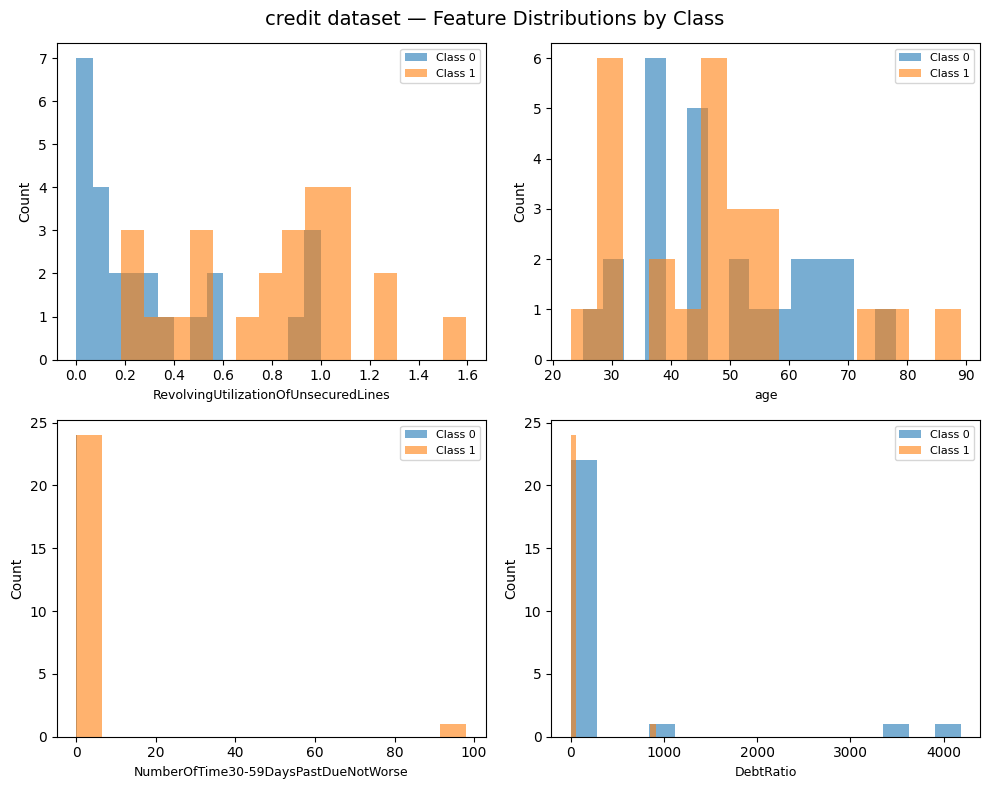

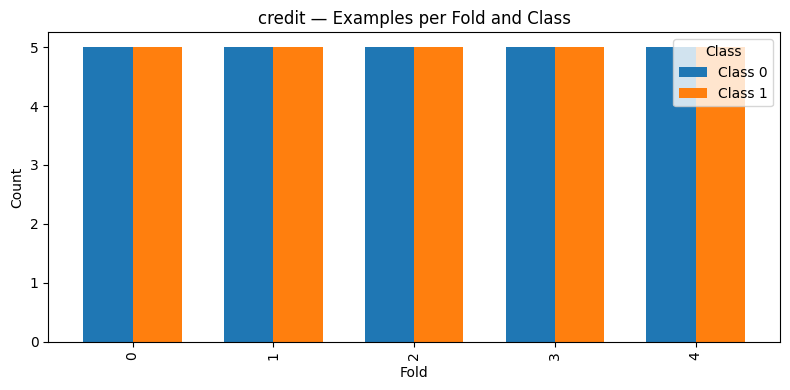

Done — visualization complete.


In [9]:
# ── Visualization: feature distributions and class/fold balance ─────────
for name, df in all_dfs.items():
    feature_cols = [c for c in df.columns if c not in ("label", "fold")]
    plot_features = feature_cols[:N_FEATURES_TO_PLOT]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"{name} dataset — Feature Distributions by Class", fontsize=14)

    for idx, feat in enumerate(plot_features):
        ax = axes[idx // 2][idx % 2]
        for label_val in sorted(df["label"].unique()):
            subset = df[df["label"] == label_val][feat].dropna()
            ax.hist(subset, bins=15, alpha=0.6, label=f"Class {label_val}")
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Fold x Class balance bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    fold_class = df.groupby(["fold", "label"]).size().unstack(fill_value=0)
    fold_class.plot(kind="bar", ax=ax, width=0.7)
    ax.set_title(f"{name} — Examples per Fold and Class")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Count")
    ax.legend(title="Class", labels=[f"Class {c}" for c in fold_class.columns])
    plt.tight_layout()
    plt.show()

print("Done — visualization complete.")